In [1]:
import numpy as np
import scipy.signal as signal
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def generate_psd(f, cutoff, n, turb_power, noise_power):
    """
    Generates the Turbulence and Noise PSDs normalized to the requested total powers.
    """
    f_safe = np.maximum(f, f[0])
    if n == 1:
        psd_turb = np.where(f_safe <= cutoff, 
                            (f_safe / cutoff)**(-2/3), 
                            (f_safe / cutoff)**(-17/3))
    else:
        psd_turb = np.where(f_safe <= cutoff, 
                            1.0, 
                            (f_safe / cutoff)**(-17/3))
        
    # Precompute integration weights for normalization
    df = np.gradient(f)
    
    turb_integral = np.sum(psd_turb * df)
    psd_turb *= (turb_power / turb_integral)
    
    psd_noise = np.ones_like(f)
    noise_integral = np.sum(psd_noise * df)
    psd_noise *= (noise_power / noise_integral)
    
    return psd_turb, psd_noise

def fit_controller_to_turbulence(params, order, w, true_turb_snr_omega):
    # Fix 1 & 2: Match the slicing used in evaluate_filter exactly
    b = params[:order+1] 
    a = params[order+1:]
    
    # Stability check for controller poles
    den_roots = np.roots(np.concatenate(([1.0], a)))
    if len(den_roots) > 0:
        max_root = np.max(np.abs(den_roots))
        if max_root >= 0.99:
            return 1e10 + (max_root - 0.99) * 1e12 # Soft penalty slope
        
    
    # Standard assignment: b is numerator, a is denominator
    num_C = b
    den_C = np.concatenate(([1.0], a))
    _, C_w = signal.freqz(num_C, den_C, worN=w)
    
    C_mag_squared = np.abs(C_w)**2
    
    # Logarithmic error (dB) to balance high and low frequencies
    error = np.sum((C_mag_squared - true_turb_snr_omega)**2)
    return error

def optimize_filter_ladder(target_order, delay_steps, fs, cutoff, n, turb_power, noise_power, 
                           restarts:int = 100, min_gain_margin_db=3.0, verbose=True):
    """
    Optimizes an IIR filter up to target_order using ladder initialization.
    """
    f = np.linspace(0.1, fs/2, 2000)#np.logspace(np.log10(0.1), np.log10(fs/2), 2000)
    
    psd_turb, psd_noise = generate_psd(f, cutoff, n, turb_power, noise_power)
    delay_phasor = np.exp(-1j * 2 * np.pi * f / fs * delay_steps)
    df = np.gradient(f) 
    
    if verbose:
        print(f"=== Starting Ladder Optimization up to Order {target_order} ===")
        print(f"Turbulence Power: {turb_power:.2e} | Noise Power: {noise_power:.2e}")

    a_opts = []
    b_opts = []
    residuals = np.zeros(target_order)
    
    # Track the padded guess from the previous order to feed into the next
    padded_guess = None 
    
    for current_order in range(1, target_order + 1):
        if verbose:
            print(f"\n--- Optimizing Order {current_order} ---")

        best_params_psd = None
        best_cost_psd = np.inf
        
        num_params = 2 * current_order + 1 
        freq = np.linspace(0.1, fs/2, 2000)
        psd_turb_lin, psd_noise_lin = generate_psd(freq, cutoff, n, turb_power, noise_power)
        w = 2 * np.pi * freq / fs
    
        # Step A: Fit to turbulence PSD
        for i in range(restarts):
            if i == 0 and padded_guess is not None:
                initial_guess = padded_guess
            else:
                initial_guess = np.random.uniform(-0.5, 0.5, num_params)
                
            res_psd = minimize(fit_controller_to_turbulence, initial_guess, 
                               args=(current_order, w, psd_turb_lin/psd_noise_lin[0]), 
                               method='Nelder-Mead', options={'maxiter': 5000})
            
            if res_psd.success and res_psd.fun < best_cost_psd:
                best_cost_psd = res_psd.fun
                best_params_psd = res_psd
                
        # Fallback just in case Nelder-Mead fails on all restarts
        if best_params_psd is not None:
            current_params = best_params_psd.x 
        else:
            current_params = padded_guess if padded_guess is not None else np.random.uniform(-0.5, 0.5, num_params)
            
        # Step B: Full residual optimization
        res = minimize(
            evaluate_filter, 
            current_params, 
            args=(current_order, f, fs, psd_turb, psd_noise, delay_phasor, df, min_gain_margin_db),
            method='Nelder-Mead', 
            options={'maxiter': 10000, 'xatol': 1e-5, 'fatol': 1e-5}
        )
        
        b_opt = res.x[:current_order+1]
        a_opt = np.concatenate(([1.0], res.x[current_order+1:]))

        b_opts.append(b_opt)
        a_opts.append(a_opt)
        residuals[current_order-1] = res.fun
        
        if verbose:
            print(f"Convergence: {'Success' if res.success else 'Failed'} ({res.message})")
            print(f"Residual Variance: {res.fun:.4e}")
            print(f"b coeffs: {b_opt}")
            print(f"a coeffs: {a_opt}")
        
        # Advance ladder: pad with tiny noise to pass to the NEXT order's initial restart
        if current_order < target_order:
            b_next = np.append(b_opt, 0.0)
            a_next = np.append(res.x[current_order+1:], 0.0) 
            padded_guess = np.concatenate((b_next, a_next))
            
    return b_opts, a_opts, residuals

def evaluate_filter(params, order, f, fs, psd_turb, psd_noise, delay_phasor, df, min_gain_margin_db=3.0):
    """
    Evaluates the residual variance for a given set of filter coefficients.
    Optimized for tight inner-loop execution.
    """
    b = params[:order+1]
    a = np.concatenate(([1.0], params[order+1:]))
    
    roots = np.roots(a)
    if len(roots) > 0:
        mags = np.abs(roots)
        # Find unstable poles
        unstable_idx = mags >= 0.99
        if np.any(unstable_idx):
            # Reflect poles inside the unit circle to maintain a smooth gradient
            roots[unstable_idx] = (0.99**2 / mags[unstable_idx]) * np.exp(1j * np.angle(roots[unstable_idx]))
            # Reconstruct the stable denominator
            a_coeffs = np.real(np.poly(roots))
    
    # 2. Compute Open Loop Transfer Function
    # worN=f passes the specific frequencies, avoiding default linspace
    _, h_filter = signal.freqz(b, a, worN=f, fs=fs)
    h_ol = h_filter * delay_phasor
    
    # 3. Smooth Gain Margin Penalty
    phase = np.unwrap(np.angle(h_ol))
    crossings = np.where(phase <= -np.pi)[0]
    
    gm_penalty = 0.0
    if len(crossings) > 0:
        idx = crossings[0]
        gm_db = -20 * np.log10(np.abs(h_ol[idx]) + 1e-15)
        if gm_db < min_gain_margin_db:
            # Softer polynomial penalty instead of a hard cliff
            gm_penalty = 100 * (min_gain_margin_db - gm_db)**2
    
    # 4. Compute Transfer Functions
    # Using element-wise arithmetic minimizes array allocations
    denom_mag2 = np.abs(1.0 + h_ol)**2
    S_mag2 = 1.0 / denom_mag2
    T_mag2 = np.abs(h_ol)**2 / denom_mag2
    
    # 5. Fast Vectorized Integration
    residual_psd = S_mag2 * psd_turb + T_mag2 * psd_noise
    total_residual = np.sqrt(np.sum(residual_psd * df))
    
    return total_residual+gm_penalty


def plot_filter_performance(fs, cutoff, n, turb_power, noise_power, filter_results, delay_steps):
    """
    Plots the PSD amplitudes and the transfer functions for comparison.
    
    filter_results: List of tuples [(b, a, "Label"), ...]
    """
    f = np.logspace(np.log10(0.1), np.log10(fs/2), 2000)
    psd_turb, psd_noise = generate_psd(f, cutoff, n, turb_power, noise_power)
    delay_phasor = np.exp(-1j * 2 * np.pi * f / fs * delay_steps)

    plt.figure(figsize=(12, 5))
    for b, a, label in filter_results:
        _, h_filter = signal.freqz(b, a, worN=f, fs=fs)
        h_ol = h_filter * delay_phasor
        S = 1.0 / (1.0 + h_ol)
        plt.loglog(f, np.abs(S), label=f'{label}')
    plt.title('RTF magnitude')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend(ncol=2, fontsize='small')
    plt.tight_layout()

    plt.figure(figsize=(12, 7))
    for b, a, label in filter_results:
        _, h_filter = signal.freqz(b, a, worN=f, fs=fs)
        h_ol = h_filter * delay_phasor
        S = 1.0 / (1.0 + h_ol)
        plt.loglog(f, np.abs(S)**-2, label=r'$RTF^{-2}$'+f'{label}')
    plt.loglog(f, psd_turb/psd_noise, label=r'Turbulence ($\sqrt{\Phi_{turb}}$)', color='blue', lw=2)
    plt.loglog(f, psd_noise/psd_noise, label=r'Noise ($\sqrt{\Phi_{noise}}$)', color='gray', linestyle='--')
    plt.title('Normalized PSD')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend(ncol=2, fontsize='small')
    plt.ylim([1e-2,psd_turb[0]/psd_noise[0]*2])

    plt.tight_layout()
    plt.show()


=== Starting Ladder Optimization up to Order 3 ===
Turbulence Power: 1.00e+02 | Noise Power: 1.00e+00

--- Optimizing Order 1 ---


/tmp/ipykernel_17419/3044750542.py:156: ComplexWarning: Casting complex values to real discards the imaginary part
  roots[unstable_idx] = (0.99**2 / mags[unstable_idx]) * np.exp(1j * np.angle(roots[unstable_idx]))


Convergence: Success (Optimization terminated successfully.)
Residual Variance: 5.3944e+00
b coeffs: [15802067.6915569  14124744.09330929]
a coeffs: [1.0000000e+00 3.3997051e+07]

--- Optimizing Order 2 ---
Convergence: Success (Optimization terminated successfully.)
Residual Variance: 1.0220e+00
b coeffs: [  6.48432987 -12.84316725   6.48434144]
a coeffs: [ 1.         -2.02837431  1.02862896]

--- Optimizing Order 3 ---
Convergence: Success (Optimization terminated successfully.)
Residual Variance: 2.1255e-01
b coeffs: [-0.03568214  0.02487958  0.01735037 -0.0261612 ]
a coeffs: [ 1.         -2.0535024   1.10770445 -0.05407725]


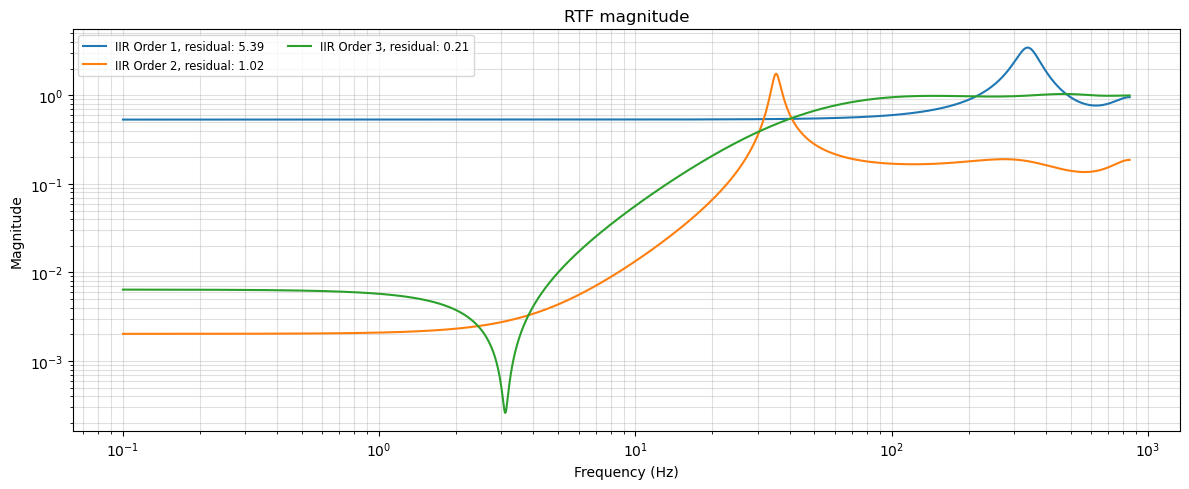

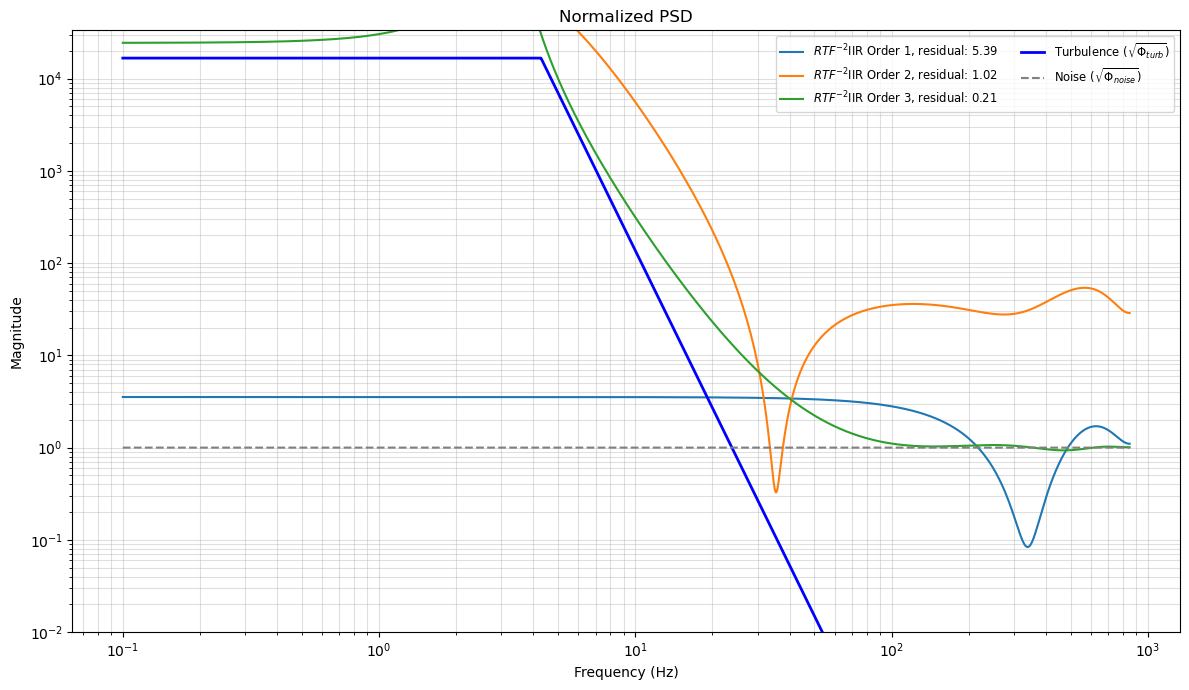

In [2]:
V = 20
D = 8.4

FS = 1700.0             
DELAY_STEPS = 3         
N_RADIAL = 5            
CUTOFF_FREQ = 0.3 * (N_RADIAL + 1) * V/D      
TURB_POWER = 100.0      
NOISE_POWER = 1       
TARGET_ORDER = 3

b_list, a_list, residuals = optimize_filter_ladder(
    target_order=TARGET_ORDER,
    delay_steps=DELAY_STEPS,
    fs=FS,
    cutoff=CUTOFF_FREQ,
    n=N_RADIAL,
    turb_power=TURB_POWER,
    noise_power=NOISE_POWER,
    verbose=True
)

results_list = []
for j in range(len(residuals)):
    results_list.append((b_list[j], a_list[j], f"IIR Order {j+1}, residual: {residuals[j]:1.2f}"))

plot_filter_performance(fs=FS, cutoff=CUTOFF_FREQ, n=N_RADIAL, turb_power=TURB_POWER, noise_power=NOISE_POWER, delay_steps=DELAY_STEPS, filter_results=results_list)

In [3]:
def build_bounds_and_init(order):
    """
    Constructs the parameter bounds and a sensible initial guess 
    based on polar coordinate pole/zero placement.
    """
    bounds = [(1e-5, 1e3)] # Overall Gain K
    init_guess = [0.1]
    
    for i in range(order // 2):
        bounds.extend([
            (0.0, 5.0), # r_z
            (0.0, np.pi), # theta_z
            (0.0, 0.985), # r_p (strict stability)
            (0.0, np.pi) # theta_p
        ])
        
        # IMPROVEMENT 1: Stagger the radii. 
        # By separating poles and zeros initially, we avoid 
        # exact cancellations and give the optimizer a non-zero gradient.
        th = np.pi * (i + 1) / (order // 2 + 1)
        r_z = 0.8
        r_p = 0.4 
        init_guess.extend([r_z, th, r_p, th])
        
    if order % 2 != 0:
        bounds.extend([
            (-5.0, 5.0), # Real zero
            (-0.985, 0.985) # Real pole
        ])
        init_guess.extend([0.5, 0.0]) # Staggered real pole/zero
        
    return bounds, np.array(init_guess)

def params_to_sos(params, order):
    # (Unchanged from your original code)
    K = params[0]
    sos = []
    idx = 1
    
    for _ in range(order // 2):
        rz, thz, rp, thp = params[idx:idx+4]
        idx += 4
        b = [1.0, -2 * rz * np.cos(thz), rz**2]
        a = [1.0, -2 * rp * np.cos(thp), rp**2]
        sos.append(b + a)
        
    if order % 2 != 0:
        rz, rp = params[idx:idx+2]
        b = [1.0, -rz, 0.0]
        a = [1.0, -rp, 0.0]
        sos.append(b + a)
        
    return K, np.array(sos)

def evaluate_filter_polar(params, order, f, fs, psd_turb, psd_noise, delay_phasor, df, max_sensitivity=2.0):
    K, sos = params_to_sos(params, order)
    
    _, h_filter = signal.sosfreqz(sos, worN=f, fs=fs)
    h_ol = K * h_filter * delay_phasor
    
    denom_mag2 = np.abs(1.0 + h_ol)**2
    denom_mag2 = np.maximum(denom_mag2, 1e-12) 
    
    S_mag2 = 1.0 / denom_mag2
    T_mag2 = np.abs(h_ol)**2 / denom_mag2
    
    # IMPROVEMENT 2: Smooth Robustness Penalty
    # The peak of the Sensitivity function is an inverse measure of 
    # the vector margin (distance to the -1 point). 
    # max(S) = 2.0 corresponds to a vector margin of 0.5.
    peak_S = np.sqrt(np.max(S_mag2))
    penalty = 0.0
    if peak_S > max_sensitivity:
        # A smooth quadratic penalty that turns on only if we violate the margin
        penalty = 1e4 * (peak_S - max_sensitivity)**2
            
    # Compute Transfer Functions
    residual_psd = S_mag2 * psd_turb + T_mag2 * psd_noise
    total_residual = np.sqrt(np.sum(residual_psd * df))
    
    return total_residual + penalty

def optimize_filter_polar(target_order, delay_steps, fs, cutoff, n, turb_power, noise_power):
    # (f, psd_turb, psd_noise generation assumed to be handled here)
    f = np.logspace(np.log10(0.1), np.log10(fs/2), 2000)
    
    # Placeholder for your PSD generation
    # psd_turb, psd_noise = generate_psd(f, cutoff, n, turb_power, noise_power)
    psd_turb, psd_noise = np.ones_like(f), np.ones_like(f) * 0.1 
    
    delay_phasor = np.exp(-1j * 2 * np.pi * f / fs * delay_steps)
    df = np.gradient(f) 
    
    bounds, current_params = build_bounds_and_init(target_order)
    
    res = minimize(
        evaluate_filter_polar, 
        current_params, 
        args=(target_order, f, fs, psd_turb, psd_noise, delay_phasor, df),
        method='L-BFGS-B', 
        bounds=bounds,
        options={'maxiter': 10000, 'ftol': 1e-9} # 'disp': True helps monitor progress
    )
    
    final_K, final_sos = params_to_sos(res.x, target_order)
    
    print(f"Convergence: {'Success' if res.success else 'Failed'} ({res.message})")
    print(f"Final Residual: {res.fun:.4e}")
    
    return final_K, final_sos

Convergence: Success (CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL)
Final Residual: 2.9186e+01
[ 1.          0.06720474  0.09198107 -0.04538331  0.        ] [ 1.         -0.62979452  0.45996627 -0.12114332  0.        ]


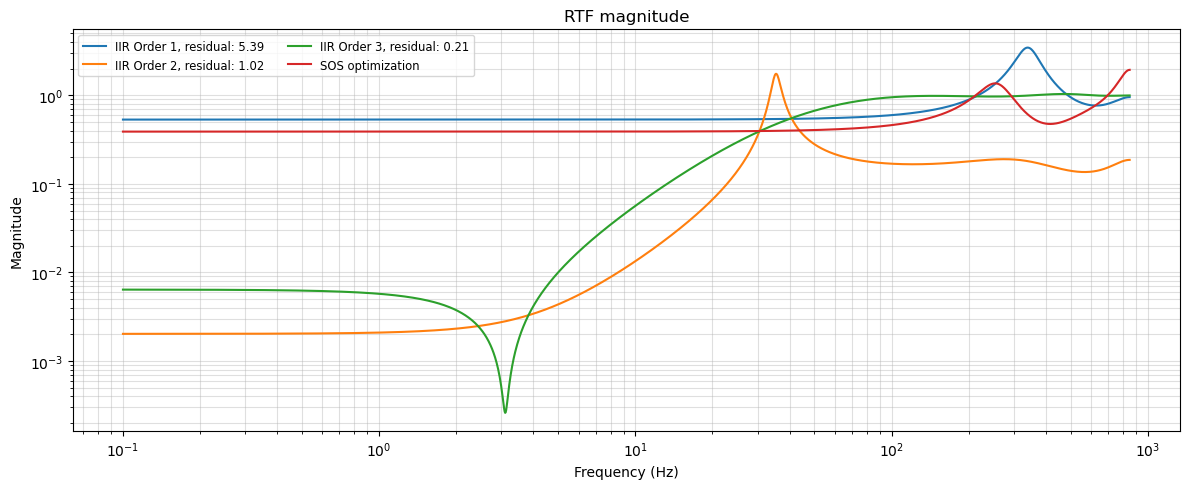

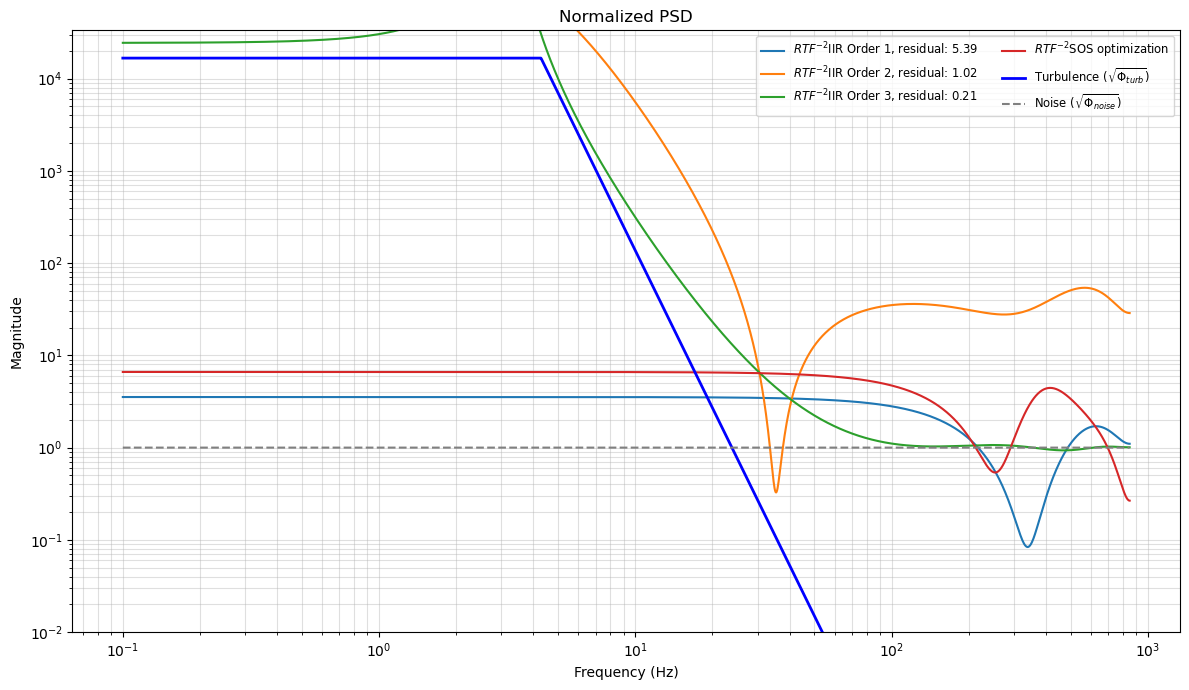

In [4]:
K,sos = optimize_filter_polar(    
    target_order=TARGET_ORDER,
    delay_steps=DELAY_STEPS,
    fs=FS,
    cutoff=CUTOFF_FREQ,
    n=N_RADIAL,
    turb_power=TURB_POWER,
    noise_power=NOISE_POWER)

# sos[0,:3] *= K
b,a = signal.sos2tf(sos)

print(b,a)

results_list.append((b, a, f"SOS optimization"))

plot_filter_performance(fs=FS, cutoff=CUTOFF_FREQ, n=N_RADIAL, turb_power=TURB_POWER, noise_power=NOISE_POWER, delay_steps=DELAY_STEPS, filter_results=results_list)


In [5]:
from scipy.signal import freqz
from scipy.fft import ifft, fft

def plot_results(f_linear, phi_turb, phi_noise, b, a, fs):
    w, h_S = freqz(b, a, worN=2000, fs=fs)
    h_T = 1 - h_S # Complementary Sensitivity (NTF)
    
    # 2. Calculate |RTF|^-2 which is |A/B|^2
    # Avoid division by zero by adding a tiny epsilon
    rtf_inv_sq = 1.0 / (np.abs(h_S)**2 + 1e-16)
    rtf_sq = np.abs(h_S)**2
    ntf_sq = np.abs(h_T)**2
    
    # 3. Create the plot
    plt.figure(figsize=(12, 7))
    
    # Plot target components
    plt.loglog(f_linear, phi_turb/phi_noise[0], label=r'Turbulence ($\Phi_{turb}$)', 
               color='blue', alpha=0.6, linestyle='--')
    plt.loglog(f_linear, phi_noise/phi_noise[0], label=r'Noise ($\Phi_{noise}$)', 
               color='gray', alpha=0.6, linestyle='--')
    
    target_total = phi_turb + phi_noise
    plt.loglog(f_linear, target_total/phi_noise[0], label=r'Target ($\Phi_{turb} + \Phi_{noise}$)', 
               color='black', linewidth=2)
    
    df = np.gradient(f_linear) 
    res_psd = rtf_sq * phi_turb + ntf_sq * phi_noise
    res = np.sqrt(np.sum(res_psd*df))

    # Plot the IIR filter result
    plt.loglog(w, rtf_inv_sq, label=f'$|RTF|^{{-2}}$ (Order {len(a)-1}) residual: {res:1.2f}', 
               color='red', linewidth=2)
    
    # Formatting
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude / PSD')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.ylim([1e-2,phi_turb[0]/phi_noise[0]*10])
    plt.legend()
    plt.tight_layout()
    plt.show()

def design_fractional_delayed_rtf(fs, cutoff,n,turb_power,noise_power, order, delay_fs):
    """
    Computes IIR filter coefficients for an optimized Rejection Transfer Function (RTF)
    controlling a plant with a pure delay, using constrained spectral factorization.
    
    Parameters:
    fs          : float, sampling frequency
    phi_turb    : 1D array, turbulence PSD
    phi_noise   : 1D array, noise PSD
    order       : int, desired order of the IIR filter (must be >= delay_steps)
    delay_fs : float, pure delay of the plant (N)
    
    Returns:
    b, a        : Numerator and denominator coefficients of the RTF S(z)
    """

    f_linear = np.linspace(0.1,fs/2,2000)
    p = order
    
    phi_turb, phi_noise = generate_psd(f_linear, cutoff, n, turb_power, noise_power)
    # 1. Minimum-Phase Disturbance Model M(z)
    mag_target = np.sqrt(phi_turb + phi_noise)
    mag_target = np.maximum(mag_target, 1e-12)
    
    log_mag_sym = np.concatenate((np.log(mag_target), np.log(mag_target[-2:0:-1])))
    n_fft = len(log_mag_sym)
    
    ceps = np.real(ifft(log_mag_sym))
    w_cep = np.zeros(n_fft)
    w_cep[0], w_cep[1:n_fft//2], w_cep[n_fft//2] = 1.0, 2.0, 1.0
        
    complex_M_sym = np.exp(fft(ceps * w_cep))
    M_freq = complex_M_sym[:len(mag_target)]
    
    # 2. Handle Fractional Delay in Target S(w)
    # The 'Ideal' error for delay tau is the part of the impulse response
    # of M that occurs before time tau.
    m_t = np.real(ifft(complex_M_sym))
    t = np.arange(n_fft)
    
    # Use a soft-window/interpolation for fractional truncation
    # Values before floor(tau) are 1, after ceil(tau) are 0, fractional in between
    window = np.clip(delay_fs + 0.5 - t, 0, 1)
    f_t = m_t * window
    
    S_target = fft(f_t)[:len(mag_target)] / M_freq
    
    # 3. Least Squares Fit (Standard Equation Error)
    w_rad = np.pi * (f_linear / (fs / 2))
    num_freqs = len(w_rad)
    
    # S(z) = B(z)/A(z)  =>  S*A - B = 0
    # Regressors for A (1 to p) and B (0 to p)
    X = np.zeros((num_freqs, 2*p + 1), dtype=complex)
    for k in range(1, p + 1):
        X[:, k-1] = -S_target * np.exp(-1j * w_rad * k) # A terms
    for k in range(p + 1):
        X[:, p + k] = np.exp(-1j * w_rad * k)          # B terms
        
    Y = S_target # Corresponds to a_0 = 1
    
    # Weight the fit by the inverse of the target PSD to prioritize rejection zones
    W = 1.0 / mag_target
    X_w = X * W[:, None]
    Y_w = Y * W
    
    X_stack = np.vstack((np.real(X_w), np.imag(X_w)))
    Y_stack = np.concatenate((np.real(Y_w), np.imag(Y_w)))
    
    theta, _, _, _ = np.linalg.lstsq(X_stack, Y_stack, rcond=None)
    
    a = np.concatenate(([1.0], theta[:p]))
    b = theta[p:]

    plot_results(f_linear, phi_turb, phi_noise, b, a, fs)
    
    return b, a

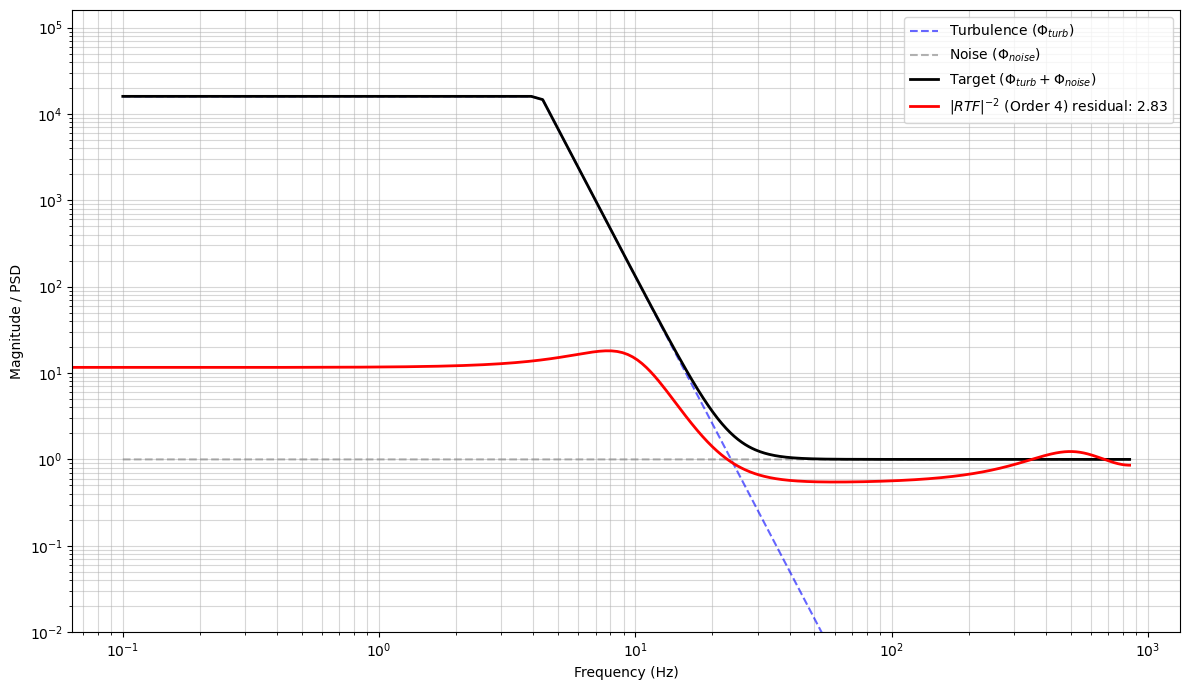

[ 0.99999282 -1.8950645   0.90080045 -0.15413464  0.15020227] [ 1.00000000e+00 -1.89507482e+00  9.00821680e-01  1.24437557e-04
  2.48918636e-04]


In [6]:
Nfilter = 4
Ndelay = 2.5
n = 10

a,b = design_fractional_delayed_rtf(fs=FS, cutoff=CUTOFF_FREQ,n=n,turb_power=TURB_POWER,noise_power=NOISE_POWER, order=Nfilter, delay_fs=Ndelay)

print(a,b)